# Figure: engagement — a 2-state GLM-HMM, and how its dynamics vary along LD1

Panels only; the analyses live elsewhere.

| panel | what | source |
|---|---|---|
| A | cartoon: the 2-state GLM-HMM (blank space, drawn in Inkscape) | — |
| B | GLM weights of the engaged and disengaged states | `GLM-HMM/load_states.ipynb` (What each state does) |
| C | empirical psychometric and chronometric curves per state | `load_states` (Average psychometric and chronometric curves) |
| D | fraction of engaged trials (hard threshold) and engaged log ratio (soft posterior) vs LD1 | `load_states` (Empirical state occupancy; Ratio of GLM-HMM states) |
| E | P(stay engaged) and P(stay disengaged) vs LD1 | `load_states` (State stickiness) |
| F | two example sessions from the ends of LD1: same share of engaged trials, different posterior and switching | as `GLM-HMM/k2_k3_pilot/low_vs_high_lda1_matched_occupancy_truncated.png` |
| G | state switches per session, sessions truncated to a common length, vs LD1 | `load_states` (n_transitions) |
| H | held-out log-likelihood gained over K = 2 by K = 3 and K = 4, vs LD1 | `GLM-HMM/k_state_model_comparison.ipynb` (sections 1, 5) |
| I | state switches per session at K = 4, truncated, vs LD1 | `k_state_model_comparison` (Just the one panel) |

**Statistics (D, E, G–I).** One family of correlations with LD1 (Pearson by default), Benjamini–Hochberg FDR over all of them; every panel prints r and the corrected p, and a fit line is drawn only where the corrected p < 0.05. `UNIT` sets what a point is: `'session'` (default, as `load_states` plots them) or `'mouse'` (session values averaged within mouse; mice contribute 1–14 sessions, so this is the more conservative test). The table for the other unit is printed too.

**LD1** comes from the pinned embedding file below for every panel, including H and I, whose source CSVs carry an older `lda_1` (r ≈ 0.93 with the current one).

Each panel is a `draw_X(fig, spec)` function; the last cell assembles them into one 180 mm figure and writes `figure_generation/figures/fig_engagement.pdf` (for LaTeX) and a dated SVG.

In [1]:
import sys, pathlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from scipy.optimize import curve_fit
from scipy.stats import pearsonr, spearmanr
from statsmodels.stats.multitest import multipletests

REPO = pathlib.Path.cwd().resolve()
while not (REPO / 'Functions' / 'trial_modes.py').exists() and REPO != REPO.parent:
    REPO = REPO.parent
PI = REPO / 'paper-individuality'
sys.path.insert(0, str(PI))
import paper_style as ps
ps.use('paper')
pd.set_option('display.width', 160)

paper_style: paper mode, spines=lb, font 8 pt, panels 3.4x2.4 in, save 400 dpi


## Parameters

In [2]:
FIG = 'fig_engagement'
LDA_FILE = PI / 'clustering' / 'data_files' / 'mouse_LDA_5_bins_raw_shrink0.5_wmouse_360_02-10-2026'
STATES_FILE = PI / 'GLM-HMM' / 'merged_behavioral_and_states.pqt'     # K=2 posteriors (engaged.py), as load_states
TRIAL_META = PI / 'data' / 'session_trial_meta_10-07-2026'           # reaction times (C)
PILOT = PI / 'GLM-HMM' / 'k2_k3_pilot'
WEIGHTS_FILE = PILOT / 'all_k_weights.csv'                           # B
LOSO_FILE = PILOT / 'loso_k2_k3_k4_k5_wide.csv'                      # H: held-out bits/trial per K
POSTERIORS_FILE = PILOT / 'all_k_posteriors.parquet'                 # I: per-trial posteriors, K = 2-4

A_PLACEHOLDER = True      # A: dashed box + note while drafting; False leaves blank space for the Inkscape cartoon
UNIT = 'session'          # C-I: 'session', or 'mouse' (session values averaged within mouse)
CORR_METHOD = 'pearson'   # or 'spearman'
FDR_METHOD = 'fdr_bh'     # multipletests method over the D-I family
H_STEPS = [(2, 3), (2, 4)]   # H: held-out gain of K over K=2, one panel each; any (a, b) up to K=5 is in LOSO_FILE
I_K = 4
N_TRUNC = 400             # D-I: occupancy and switching counted over each session's first N_TRUNC trials (shortest: 401)
LD1_COLOR_VMAX = 9.83     # LD1 colour scale, +/- this: fig_ld1's (max |LD1| of its panel-C sessions); beyond it saturates
EXAMPLE_SESSIONS = None        # F: (low-LD1 eid prefix, high-LD1 eid prefix), e.g. ('837b4e6a', '4fa70097'); None picks them
EXAMPLE_LD1_QUANTILE = 0.2     # F: each example comes from this tail of LD1
EXAMPLE_MAX_FRAC_DIFF = 0.01   # F: their fractions of engaged trials differ by at most this
RT_WINDOW = (0, 2)        # C: s, the IBL inclusion window used in load_states
MIN_TRIALS_PER_CELL = 5   # C: a session x state x contrast cell needs this many trials

## Data

* `lda`: the saved embedding (260 sessions, 56 mice); LD1 is column 0.
* `trials`: one row per trial of the K=2 GLM-HMM posteriors, restricted to LDA sessions (244). A trial is engaged when P(engaged) ≥ 0.5. `choice_right` as in `load_states` (from stimulus side and reward, so it does not touch the mirrored choice strings).
* `trials_eq`: every session truncated to its first `N_TRUNC` (400) trials, just under the shortest session (401), so that per-session occupancy and switching are counted over the same number of trials (as `load_states`).

In [3]:
def read_lda(path):
    try:
        return pd.read_pickle(path)
    except ModuleNotFoundError:     # pickled under numpy 2, read under numpy 1
        import numpy.core.numeric, numpy.core.multiarray
        for name, mod in [('numpy._core', np.core), ('numpy._core.numeric', np.core.numeric),
                          ('numpy._core.multiarray', np.core.multiarray)]:
            sys.modules.setdefault(name, mod)
        return pd.read_pickle(path)

lda = read_lda(LDA_FILE).rename(columns={0: 'LD1'})
LD1 = lda.set_index('session')['LD1']
MOUSE = lda.set_index('session')['mouse_name']

trials = pd.read_parquet(STATES_FILE)
trials = trials[trials['eid'].isin(LD1.index)].copy()
trials['trial_id'] = trials.groupby('eid').cumcount()
trials['engaged'] = trials['p_state1'] >= 0.5
trials['choice_right'] = ((trials['contrastLeft'].isna() & (trials['rewarded'] == 1))
                          | (trials['contrastRight'].isna() & (trials['rewarded'] == -1))).astype(int)
trials['correct'] = (trials['rewarded'] == 1).astype(int)

# reaction times: session_trial_meta's trial_id is the trial's position in the session; the
# alignment is checked on the posterior itself, which both files carry
meta = pd.read_parquet(TRIAL_META, columns=['session', 'trial_id', 'reaction', 'p_state1'])
trials = trials.merge(meta.rename(columns={'session': 'eid', 'p_state1': 'p_meta'}), on=['eid', 'trial_id'], how='left')
has_rt = trials['p_meta'].notna()
assert np.allclose(trials.loc[has_rt, 'p_state1'], trials.loc[has_rt, 'p_meta']), 'RT file not aligned'
trials['rt'] = trials['reaction'].where(trials['reaction'].between(*RT_WINDOW))

assert N_TRUNC <= trials.groupby('eid').size().min(), 'a session is shorter than N_TRUNC'
trials_eq = trials[trials['trial_id'] < N_TRUNC]
print(f"{trials['eid'].nunique()} sessions, {trials['animal'].nunique()} mice, {len(trials)} trials, "
      f"{1 - trials['engaged'].mean():.1%} disengaged; RT for {has_rt.mean():.1%} of trials")
print(f'occupancy / switching counted over the first {N_TRUNC} trials of every session')

244 sessions, 56 mice, 152677 trials, 13.2% disengaged; RT for 95.2% of trials
occupancy / switching counted over the first 400 trials of every session


## Panel A — the 2-state GLM-HMM (cartoon)

Left empty for the Inkscape drawing. What it has to show: on each trial the choice is a logistic regression (GLM) on stimulus, previous choice, win-stay/lose-switch and bias; the GLM's weights depend on a hidden state (engaged / disengaged) that persists across trials with a Markov transition matrix (P(stay engaged), P(stay disengaged)); the posterior P(engaged) per trial.

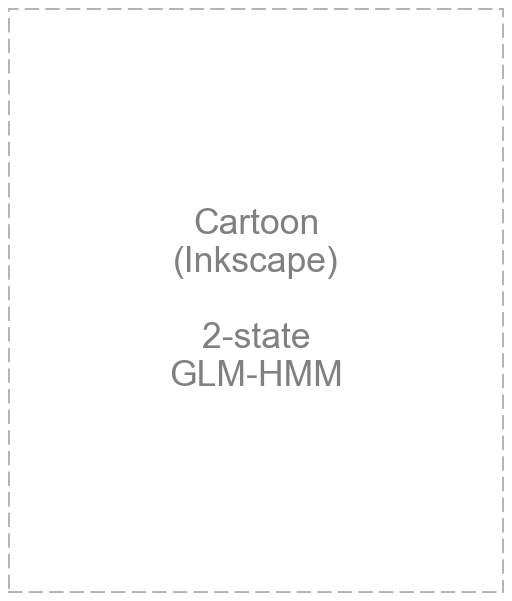

In [4]:
fs_small = plt.rcParams['font.size'] * 0.8

def draw_A(fig, spec):
    ax = fig.add_subplot(spec)
    ax.set_axis_off()
    if A_PLACEHOLDER:
        ax.add_patch(Rectangle((0, 0), 1, 1, transform=ax.transAxes, fill=False, ec='0.7', ls='--', lw=0.7))
        ax.text(0.5, 0.5, 'Cartoon\n(Inkscape)\n\n2-state\nGLM-HMM',
                ha='center', va='center', transform=ax.transAxes, fontsize=fs_small, color='0.5')
    return [ax]

fig = plt.figure(figsize=(1.6, 1.9)); draw_A(fig, fig.add_gridspec(1, 1)[0]); plt.show()

## Panel B — what each state does: the GLM weights

As `load_states`: mean ± SEM across mice of each coefficient, read from `all_k_weights.csv` (the K=2 rows of `fit_k_general.py`, a refit for the same mice, not the identical object behind the posteriors). Per mouse the engaged state is the one with the larger |stimulus weight| (EM label-switching makes the index meaningless across mice). Weights are sign-flipped so they are for the **right** choice (ssm stores the logit of y = 0, which engaged.py codes as left). Stimulus is an order of magnitude larger than the rest, so it gets its own axis. The signed bias cancels across mice (each leans its own way); |bias| is printed.

54 mice
            stim       prev_choice        wsls        bias       abs_bias      
            mean   sem        mean   sem  mean   sem  mean   sem     mean   sem
role                                                                           
disengaged  1.03  0.11        1.22  0.16  0.28  0.08  0.21  0.16     0.89  0.10
engaged     8.23  0.38        0.43  0.04  0.22  0.03 -0.02  0.09     0.50  0.06


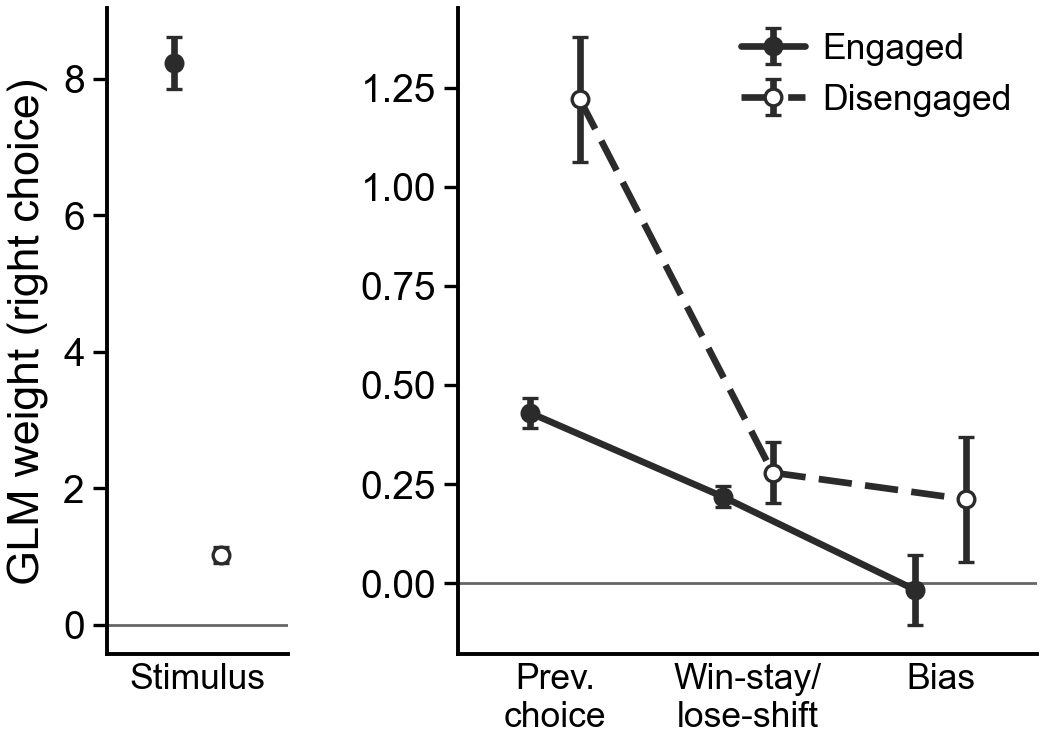

In [5]:
COEFS = ['stim', 'prev_choice', 'wsls', 'bias']
COEF_LABEL = {'stim': 'Stimulus', 'prev_choice': 'Prev.\nchoice', 'wsls': 'Win-stay/\nlose-shift', 'bias': 'Bias'}
w2 = pd.read_csv(WEIGHTS_FILE).query('K == 2').copy()
w2['abs_stim'] = w2['stim'].abs()
w2['role'] = np.where(w2['abs_stim'] == w2.groupby('mouse_name')['abs_stim'].transform('max'), 'engaged', 'disengaged')
w2[COEFS] = -w2[COEFS]
w2['abs_bias'] = w2['bias'].abs()
print(f"{w2['mouse_name'].nunique()} mice")
print(w2.groupby('role')[COEFS + ['abs_bias']].agg(['mean', 'sem']).round(2).to_string())

def draw_B(fig, spec, legend=True):
    g = spec.subgridspec(1, 2, width_ratios=[1, 3.2], wspace=0.45)
    axes = [fig.add_subplot(g[0]), fig.add_subplot(g[1])]
    for ax, coefs, leg in [(axes[0], ['stim'], False), (axes[1], COEFS[1:], legend)]:
        x = np.arange(len(coefs))
        for off, role in zip((-0.13, 0.13), ps.STATE_ORDER):
            sub = w2[w2['role'] == role]
            ax.errorbar(x + off, [sub[c].mean() for c in coefs], yerr=[sub[c].sem() for c in coefs],
                        capsize=1.5, ms=3, **ps.state_kw(role, 'marker', label=leg))
        ps.zero_line(ax)
        ax.set_xticks(x); ax.set_xticklabels([COEF_LABEL[c] for c in coefs], fontsize=fs_small)
        ax.set_xlim(-0.5, len(coefs) - 0.5)
        ax.tick_params(axis='x', length=0)
    axes[0].set_ylabel('GLM weight (right choice)')
    if legend:
        axes[1].legend(frameon=False, fontsize=fs_small, loc='upper right', handlelength=1.8)
    return axes

fig = plt.figure(figsize=(3, 2.1)); draw_B(fig, fig.add_gridspec(1, 1)[0]); plt.show()

## Panel C — psychometric and chronometric curves per state

As `load_states`, with trials labelled by their most probable state: per session × state × contrast, P(right) and median RT (RT in `RT_WINDOW`; cells with fewer than `MIN_TRIALS_PER_CELL` trials dropped), then mean ± SEM across `UNIT`s (with `UNIT = 'mouse'`, session values are averaged within mouse first). The sigmoid is drawn only where its fit is constrained; the disengaged average is flat partly because its bias direction differs between sessions and cancels (`load_states`, bias spread). RT never enters the model, so the chronometric is the independent check on what the states are.

state   disengaged  engaged
cx                         
0.0000       0.290    0.270
0.0625       0.248    0.206
0.1250       0.248    0.179
0.2500       0.199    0.160
1.0000       0.145    0.138


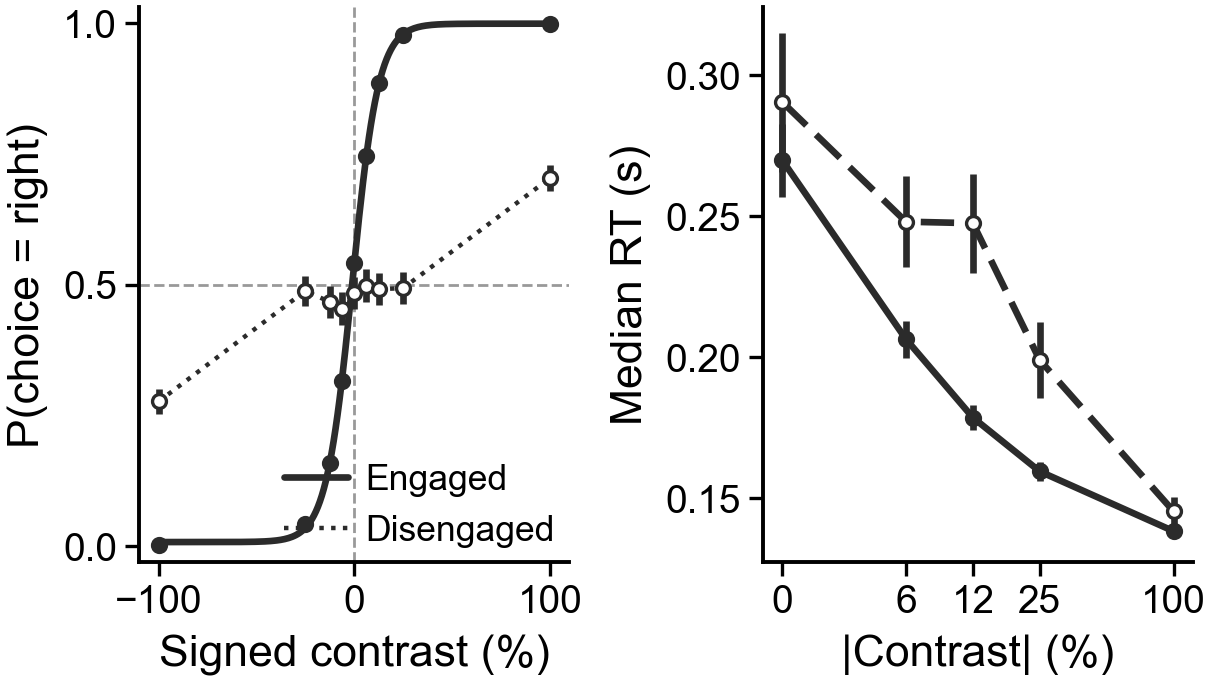

In [6]:
def sigmoid(x, mu, sigma, gamma, lambda_):
    return gamma + (1 - gamma - lambda_) / (1 + np.exp(-(x - mu) / sigma))

SIG_BOUNDS = ([-100, 0.1, 0, 0], [100, 100, 0.4, 0.4])

def fit_sigmoid(x, y):
    # None where the fit runs into its bounds (a flat curve has no finite slope)
    try:
        popt, _ = curve_fit(sigmoid, x, y, p0=[0, 10, 0.05, 0.05], bounds=SIG_BOUNDS)
    except Exception:
        return None
    at_bound = np.any(np.isclose(popt, SIG_BOUNDS[1], atol=1e-3)) or np.isclose(abs(popt[0]), 100, atol=1e-3)
    return None if at_bound else popt

def state_curves(signed):
    d = trials.assign(state=np.where(trials['engaged'], 'engaged', 'disengaged'),
                      cx=trials['signed_contrast'] if signed else trials['signed_contrast'].abs())
    cell = (d.groupby(['state', 'cx', 'eid', 'animal'])
             .agg(p_right=('choice_right', 'mean'), rt=('rt', 'median'), n=('choice_right', 'size')).reset_index())
    cell = cell[cell['n'] >= MIN_TRIALS_PER_CELL]
    if UNIT == 'mouse':
        cell = cell.groupby(['state', 'cx', 'animal'])[['p_right', 'rt']].mean().reset_index()
    return cell.groupby(['state', 'cx']).agg(p_right=('p_right', 'mean'), p_right_sem=('p_right', 'sem'),
                                             rt=('rt', 'mean'), rt_sem=('rt', 'sem'), n=('p_right', 'size')).reset_index()

C_PSY, C_CHRONO = state_curves(signed=True), state_curves(signed=False)
print(C_CHRONO.pivot(index='cx', columns='state', values='rt').round(3))

def draw_C(fig, spec, legend=True):
    g = spec.subgridspec(1, 2, wspace=0.45)
    ax_p, ax_c = fig.add_subplot(g[0]), fig.add_subplot(g[1])
    for s in ps.STATE_ORDER:
        p = C_PSY[C_PSY['state'] == s].sort_values('cx')
        x = p['cx'].to_numpy() * 100
        ax_p.errorbar(x, p['p_right'], yerr=p['p_right_sem'], ms=2.5, capsize=0,
                      **ps.state_kw(s, 'marker', label=False, ls='none'))
        popt = fit_sigmoid(x, p['p_right'].to_numpy())
        if popt is not None:
            xs = np.linspace(-100, 100, 200)
            ax_p.plot(xs, sigmoid(xs, *popt), **ps.state_kw(s, 'line', label=legend))
        else:   # dotted, since dashed already means disengaged
            ax_p.plot(x, p['p_right'], color=ps.STATE_INK, ls=':', lw=0.8, label=ps.STATE_LABEL[s] if legend else None)
        c = C_CHRONO[C_CHRONO['state'] == s].sort_values('cx')
        ax_c.errorbar(c['cx'] * 100, c['rt'], yerr=c['rt_sem'], ms=2.5, capsize=0, **ps.state_kw(s, 'marker', label=False))
    for f, v in [(ax_p.axhline, 0.5), (ax_p.axvline, 0)]:
        f(v, color='0.6', ls='--', lw=0.5, zorder=0)
    ax_p.set_ylim(-0.03, 1.03); ax_p.set_yticks([0, 0.5, 1]); ax_p.set_xticks([-100, 0, 100])
    ax_p.set_xlabel('Signed contrast (%)'); ax_p.set_ylabel('P(choice = right)')
    ax_c.set_xscale('symlog', linthresh=6.25, linscale=0.5)
    ax_c.set_xticks([0, 6.25, 12.5, 25, 100]); ax_c.set_xticklabels(['0', '6', '12', '25', '100'])
    ax_c.xaxis.set_minor_locator(plt.NullLocator())
    ax_c.set_xlabel('|Contrast| (%)'); ax_c.set_ylabel('Median RT (s)')
    if legend:
        ax_p.legend(frameon=False, fontsize=fs_small, loc='lower right', handlelength=1.8, borderaxespad=0)
    return [ax_p, ax_c]

fig = plt.figure(figsize=(3.4, 1.8)); draw_C(fig, fig.add_gridspec(1, 1)[0]); plt.show()

## Session measures for D, E, G–I

Over each session's first `N_TRUNC` trials (D, E, G: the K=2 posteriors of `merged_behavioral_and_states`):

* **D** fraction of trials engaged (P(engaged) ≥ 0.5), and the engaged log ratio: log of mean P(engaged) / mean P(disengaged) — the soft occupancy, which keeps the posterior's graded uncertainty that the hard threshold throws away.
* **E** P(stay engaged), P(stay disengaged): the diagonal of the empirical trial-to-trial transition matrix of the hard labels; undefined (dropped) in sessions that never visit the state.
* **G** number of state switches (hard label flips).

**H** held-out bits/trial gained over K = 2 by K = 3 and by K = 4 (`H_STEPS`), leave-one-session-out (each session scored by a model fit on that mouse's other sessions; `loso_k*_sweep.py`). **I** state switches at K = 4 (most probable of the 4 states per trial, full-data fits per mouse), over each session's first trials as in G (from the per-trial posteriors, so whole-session length does not inflate the count).

Note (from `load_states`): the difference between the two D measures is mostly G — sessions that switch more spend more trials at ambiguous posteriors, which lowers the soft occupancy without moving the hard one (LD1 vs log ratio partialling out switches: r = 0.11, n.s.).

In [7]:
def session_measures(t):
    def per_session(g):
        e = g['engaged'].to_numpy()
        a, b = e[:-1], e[1:]
        return pd.Series({
            'frac_engaged': e.mean(),
            'log_ratio': np.log(g['p_state1'].mean() / g['p_state2'].mean()),
            'p_stay_eng': (a & b).sum() / a.sum() if a.sum() else np.nan,
            'p_stay_dis': (~a & ~b).sum() / (~a).sum() if (~a).sum() else np.nan,
            'switches': (a != b).sum()})
    return t.groupby('eid')[['engaged', 'p_state1', 'p_state2']].apply(per_session)

SESS = session_measures(trials_eq)

# H: held-out gain per added state
loso = pd.read_csv(LOSO_FILE).set_index('held_out_session')
for a, b in H_STEPS:
    SESS = SESS.join((loso[f'bpt_K{b}'] - loso[f'bpt_K{a}']).rename(f'gain_{a}{b}'), how='outer')

# I: switches at K = I_K over the first trials of each session
post = pd.read_parquet(POSTERIORS_FILE, filters=[('K', '==', I_K)], columns=['eid', 'trial_idx', 'state', 'posterior'])
dom = (post.sort_values('posterior').drop_duplicates(['eid', 'trial_idx'], keep='last')
           .sort_values(['eid', 'trial_idx']))
N_TRUNC_I = N_TRUNC
assert N_TRUNC_I <= dom.groupby('eid').size().min()
dom = dom[dom['trial_idx'] < N_TRUNC_I]
SESS = SESS.join(dom.groupby('eid')['state'].agg(lambda s: int((np.diff(s.to_numpy()) != 0).sum()))
                    .rename(f'switches_k{I_K}'), how='outer')

SESS = SESS[SESS.index.isin(LD1.index)]
SESS.insert(0, 'LD1', LD1.reindex(SESS.index))
SESS.insert(0, 'mouse_name', MOUSE.reindex(SESS.index))
print(f'K={I_K} switches over the first {N_TRUNC_I} trials')
print(SESS.notna().sum().to_string())

K=4 switches over the first 400 trials
mouse_name      244
LD1             244
frac_engaged    244
log_ratio       244
p_stay_eng      244
p_stay_dis      228
switches        244
gain_23         231
gain_24         231
switches_k4     231


### The D, E, G–I family: correlations with LD1, FDR-corrected

One row per scatter panel. `r`, `p` raw; `p_fdr` corrected over the whole family (that is the p every panel prints, and the line is drawn where it is < 0.05).

In [8]:
TESTS = {   # key -> (panel, column, y label, title)
    'D1': ('D', 'frac_engaged', 'Fraction of trials', 'Engaged trials'),
    'D2': ('D', 'log_ratio', 'log P(eng.) / P(dis.)', 'Engaged log ratio'),
    'E1': ('E', 'p_stay_eng', 'P(stay)', 'Stay engaged'),
    'E2': ('E', 'p_stay_dis', 'P(stay)', 'Stay disengaged'),
    'G':  ('G', 'switches', f'Switches / {N_TRUNC} trials', 'State switches'),
    **{f'H{i + 1}': ('H', f'gain_{a}{b}', 'Held-out gain (bits/trial)', f'K = {a} → {b}')
       for i, (a, b) in enumerate(H_STEPS)},
    'I':  ('I', f'switches_k{I_K}', f'Switches / {N_TRUNC_I} trials', f'State switches, K = {I_K}'),
}

def unit_frame(unit):
    if unit == 'session':
        return SESS
    return SESS.groupby('mouse_name').mean(numeric_only=True)   # NaN-skipping: a mouse needs one defined session

def stats_table(unit):
    d, rows = unit_frame(unit), []
    for key, (panel, col, *_) in TESTS.items():
        ok = d[['LD1', col]].dropna()
        f = pearsonr if CORR_METHOD == 'pearson' else spearmanr
        r, p = f(ok['LD1'], ok[col])
        rows.append(dict(key=key, measure=col, n=len(ok), r=r, p=p))
    t = pd.DataFrame(rows).set_index('key')
    t['p_fdr'] = multipletests(t['p'], method=FDR_METHOD)[1]
    t['significant'] = t['p_fdr'] < 0.05
    return t

STATS = stats_table(UNIT)
OTHER = 'session' if UNIT == 'mouse' else 'mouse'
print(f'{UNIT} level ({CORR_METHOD}, {FDR_METHOD}) -- the one drawn:')
print(STATS.round(4).to_string())
print(f'\nfor reference, {OTHER} level:')
print(stats_table(OTHER).round(4).to_string())
DATA = unit_frame(UNIT)

session level (pearson, fdr_bh) -- the one drawn:
          measure    n       r       p   p_fdr  significant
key                                                        
D1   frac_engaged  244  0.0371  0.5640  0.5640        False
D2      log_ratio  244  0.2386  0.0002  0.0003         True
E1     p_stay_eng  244  0.3174  0.0000  0.0000         True
E2     p_stay_dis  228  0.1679  0.0111  0.0178         True
G        switches  244 -0.3418  0.0000  0.0000         True
H1        gain_23  231 -0.0899  0.1731  0.1978        False
H2        gain_24  231 -0.1504  0.0222  0.0296         True
I     switches_k4  231 -0.2612  0.0001  0.0002         True

for reference, mouse level:
          measure   n       r       p   p_fdr  significant
key                                                       
D1   frac_engaged  56  0.0040  0.9764  0.9764        False
D2      log_ratio  56  0.2479  0.0654  0.1308        False
E1     p_stay_eng  56  0.3968  0.0025  0.0098         True
E2     p_stay_dis  56  0.2

## Panels D, E, G–I

Drawn as `fig_ld1`'s correlation panels: one point per session (per mouse with `UNIT = 'mouse'`), coloured on one LD1 scale shared by all panels, square axes, r and the FDR-corrected p inside the axes (in the emptiest corner), line only where significant.

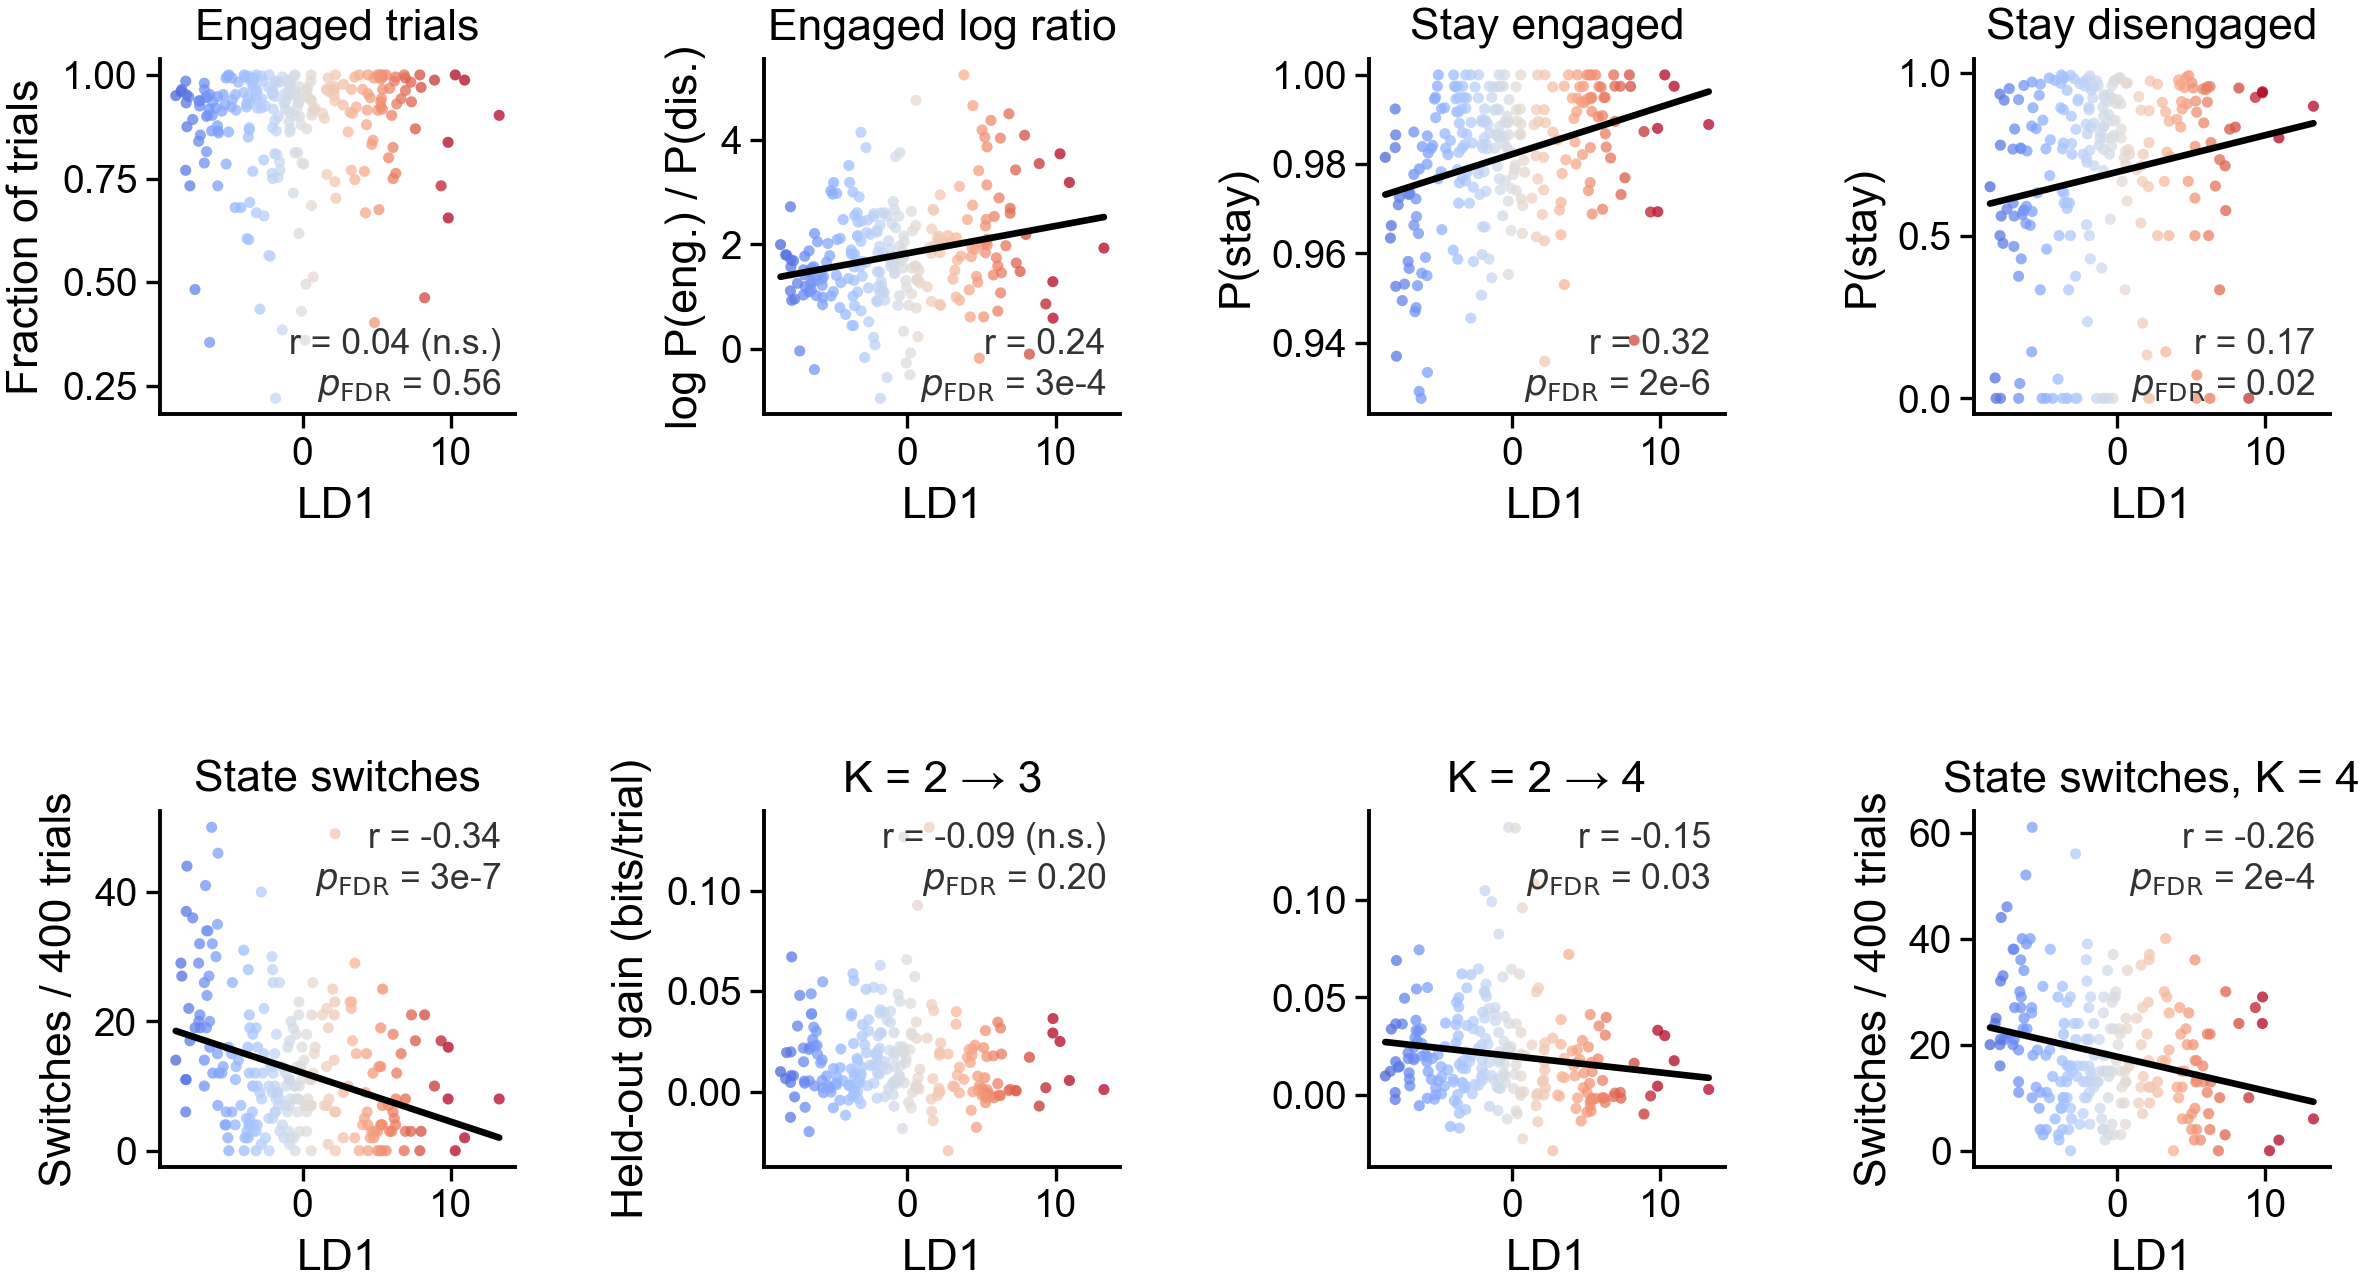

In [9]:
LD1_NORM = ps.ld1_norm([LD1_COLOR_VMAX])   # the same colours as fig_ld1

def fmt_p(p):
    return f'{p:.2f}' if p >= 0.01 else f'{p:.3f}' if p >= 0.001 else f'{p:.0e}'.replace('e-0', 'e-')

CORNERS = {'upper left': (0.04, 0.97, 'left', 'top'), 'upper right': (0.96, 0.97, 'right', 'top'),
           'lower left': (0.04, 0.03, 'left', 'bottom'), 'lower right': (0.96, 0.03, 'right', 'bottom')}

def stats_text(ax, x, y, st):
    # r and p in the corner holding the fewest points (and none of the fit line)
    u = (x - ax.get_xlim()[0]) / np.ptp(ax.get_xlim())
    v = (y - ax.get_ylim()[0]) / np.ptp(ax.get_ylim())
    if st['significant']:
        m, b = np.polyfit(x, y, 1)
        xs = np.linspace(x.min(), x.max(), 50)
        u = np.r_[u, np.repeat((xs - ax.get_xlim()[0]) / np.ptp(ax.get_xlim()), 5)]
        v = np.r_[v, np.repeat((m * xs + b - ax.get_ylim()[0]) / np.ptp(ax.get_ylim()), 5)]
    def crowd(c):
        xa, ya, ha, va = CORNERS[c]
        inx = u < 0.5 if ha == 'left' else u > 0.5
        iny = v > 0.75 if va == 'top' else v < 0.25
        return (inx & iny).sum()
    xa, ya, ha, va = CORNERS[min(CORNERS, key=crowd)]
    ax.text(xa, ya, f"r = {st['r']:.2f}{'' if st['significant'] else ' (n.s.)'}\n"
            + r'$p_\mathrm{FDR}$' + f" = {fmt_p(st['p_fdr'])}", transform=ax.transAxes,
            ha=ha, va=va, fontsize=fs_small, color='0.2', zorder=5)

def corr_ax(ax, key, ylabel=True):
    _, col, ylab, title = TESTS[key]
    st = STATS.loc[key]
    d = DATA[['LD1', col]].dropna()
    x, y = d['LD1'].to_numpy(), d[col].to_numpy()
    # fig_ld1's correlation panel: one LD1 colour scale for every panel, square axes, numbers inside
    ax.scatter(x, y, s=4, lw=0, alpha=0.75, color=ps.LD1_CMAP(LD1_NORM(x)))
    ps.regline(ax, x, y, st['significant'])
    ax.set_box_aspect(1)
    stats_text(ax, x, y, st)
    ax.set_title(title, fontsize=plt.rcParams['font.size'])
    ax.set_xlabel('LD1' + (' (mouse mean)' if UNIT == 'mouse' else ''))
    if ylabel:
        ax.set_ylabel(ylab)
    return ax

def draw_single(key):
    def draw(fig, spec):
        return [corr_ax(fig.add_subplot(spec), key)]
    return draw

def draw_pair(keys, ylabels):
    # spec: one subplot spec to split, or a list of specs (one per axis) taken from a shared grid
    def draw(fig, spec):
        if not isinstance(spec, list):
            g = spec.subgridspec(1, len(keys), wspace=0.6)
            spec = [g[i] for i in range(len(keys))]
        return [corr_ax(fig.add_subplot(sp), k, ylabel=yl) for sp, k, yl in zip(spec, keys, ylabels)]
    return draw

draw_G, draw_I = draw_single('G'), draw_single('I')
draw_D = draw_pair(['D1', 'D2'], [True, True])
draw_E = draw_pair(['E1', 'E2'], [True, True])
H_KEYS = [f'H{i + 1}' for i in range(len(H_STEPS))]
draw_H = draw_pair(H_KEYS, [True] + [False] * (len(H_KEYS) - 1))

fig = plt.figure(figsize=(7, 3.8))
g = fig.add_gridspec(2, 4, wspace=0.7, hspace=0.8)
draw_D(fig, [g[0, 0], g[0, 1]]); draw_E(fig, [g[0, 2], g[0, 3]])
draw_G(fig, g[1, 0]); draw_H(fig, [g[1, 1 + i] for i in range(len(H_STEPS))]); draw_I(fig, g[1, 1 + len(H_STEPS)])
plt.show()

## Panel F — two example sessions from the two ends of LD1

The same share of engaged trials, but not the same engagement: P(engaged) over the first `N_TRUNC` trials of one low-LD1 and one high-LD1 session (as the temporary `GLM-HMM/k2_k3_pilot/low_vs_high_lda1_matched_occupancy_truncated.png`). Grey = trials labelled disengaged (P < 0.5). With `EXAMPLE_SESSIONS = None` the pair is picked: one session from each `EXAMPLE_LD1_QUANTILE` tail of LD1, fractions engaged within `EXAMPLE_MAX_FRAC_DIFF`, as different as possible in switches. The temporary figure's pair (PL033 `837b4e6a`, DY_010 `4fa70097`) differ by 5 points in fraction engaged over this window, so it is not the default.

                                     mouse_name    LD1  frac_engaged  mean_p_engaged  switches
eid                                                                                           
3663d82b-f197-4e8b-b299-7b803a155b84    CSHL052 -6.546         0.945           0.776      41.0
ae8787b1-4229-4d56-b0c2-566b61a25b77    NR_0027  4.571         0.945           0.871       2.0


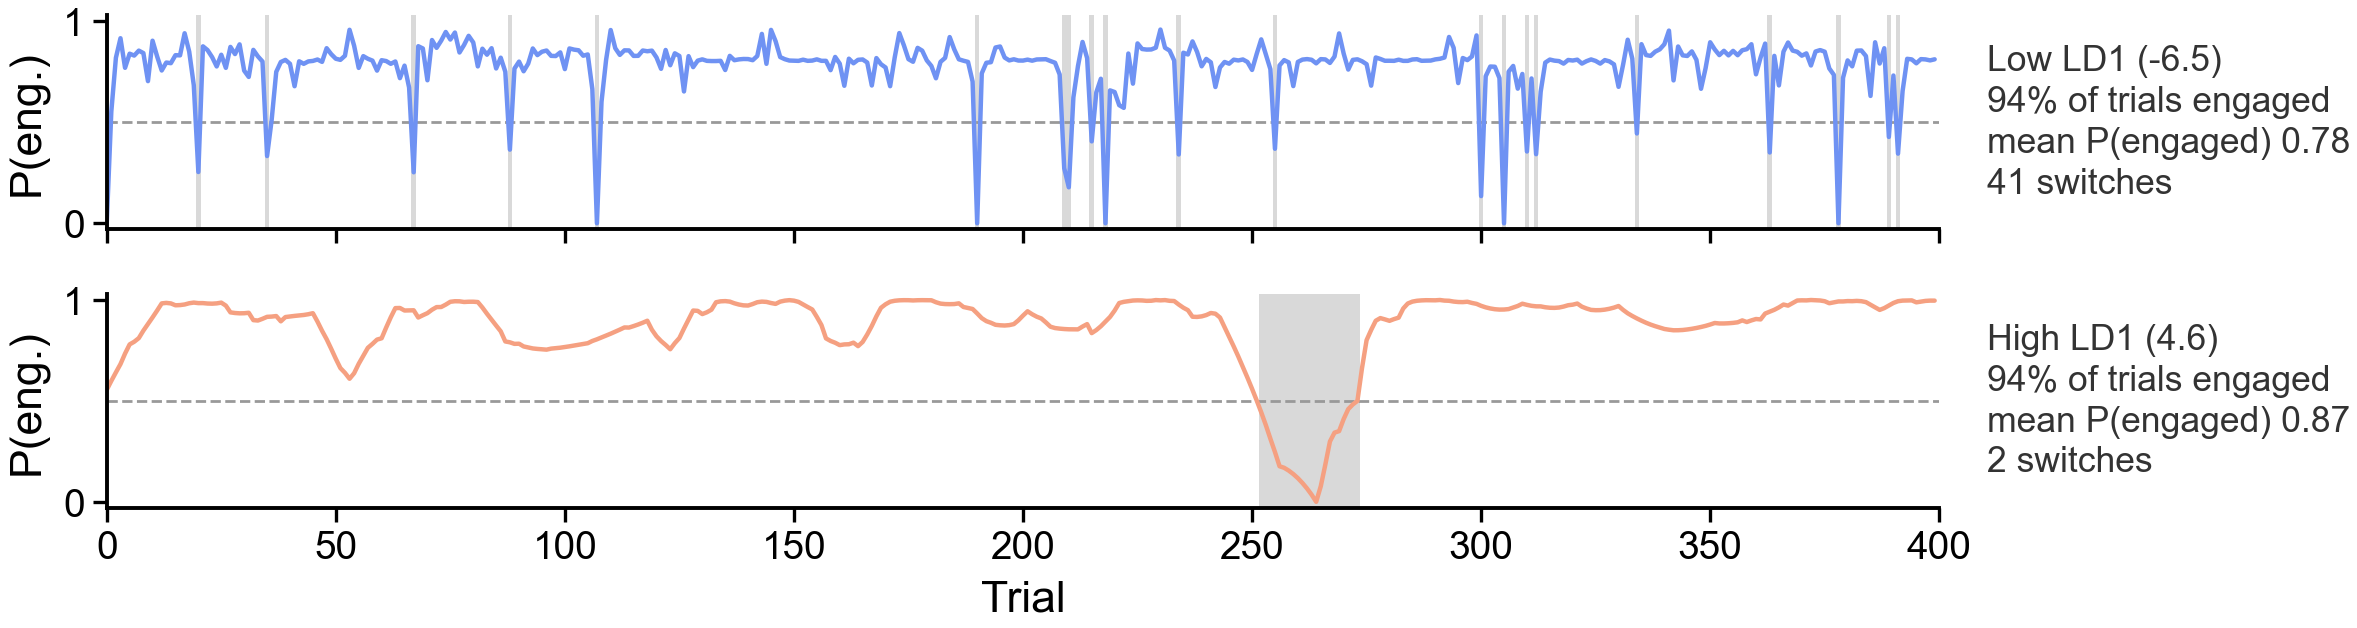

In [10]:
S_EX = SESS.rename_axis('eid').reset_index().dropna(subset=['frac_engaged'])
S_EX = S_EX.merge(trials_eq.groupby('eid')['p_state1'].mean().rename('mean_p_engaged').reset_index(), on='eid')
if EXAMPLE_SESSIONS is None:
    q = EXAMPLE_LD1_QUANTILE
    cols = ['eid', 'frac_engaged', 'switches']
    pairs = S_EX.loc[S_EX['LD1'] <= S_EX['LD1'].quantile(q), cols].merge(
        S_EX.loc[S_EX['LD1'] >= S_EX['LD1'].quantile(1 - q), cols], how='cross', suffixes=('_lo', '_hi'))
    pairs['d_frac'] = (pairs['frac_engaged_lo'] - pairs['frac_engaged_hi']).abs()
    pairs['d_switch'] = (pairs['switches_lo'] - pairs['switches_hi']).abs()
    best = pairs[pairs['d_frac'] <= EXAMPLE_MAX_FRAC_DIFF].sort_values(['d_switch', 'd_frac'], ascending=[False, True]).iloc[0]
    EXAMPLES = [best['eid_lo'], best['eid_hi']]
else:
    EXAMPLES = [next(e for e in S_EX['eid'] if e.startswith(x)) for x in EXAMPLE_SESSIONS]
EX = S_EX.set_index('eid').loc[EXAMPLES]
print(EX[['mouse_name', 'LD1', 'frac_engaged', 'mean_p_engaged', 'switches']].round(3).to_string())

def draw_F(fig, spec):
    g = spec.subgridspec(2, 2, width_ratios=[6, 1], hspace=0.3, wspace=0.03)
    axes = []
    for i, eid in enumerate(EXAMPLES):
        ax = fig.add_subplot(g[i, 0], sharex=axes[0] if axes else None); axes.append(ax)
        t, r = trials_eq[trials_eq['eid'] == eid], EX.loc[eid]
        dis = t.loc[~t['engaged'], 'trial_id']
        ax.bar(dis, 1.06, width=1, bottom=-0.03, color='0.85', lw=0, zorder=0)   # one grey bar per disengaged trial
        ax.axhline(0.5, color='0.6', ls='--', lw=0.5)
        ax.plot(t['trial_id'], t['p_state1'], color=ps.LD1_CMAP(LD1_NORM(r['LD1'])), lw=0.8)
        ax.set_ylim(-0.03, 1.03); ax.set_yticks([0, 1]); ax.set_ylabel('P(eng.)')
        ax.set_xlim(0, N_TRUNC)
        note = fig.add_subplot(g[i, 1]); note.set_axis_off()
        note.text(0.05, 0.5, f"{'Low' if i == 0 else 'High'} LD1 ({r['LD1']:.1f})\n"
                  f"{r['frac_engaged']:.0%} of trials engaged\nmean P(engaged) {r['mean_p_engaged']:.2f}\n"
                  f"{int(r['switches'])} switches", transform=note.transAxes, ha='left', va='center',
                  fontsize=fs_small, color='0.2', linespacing=1.3)
    axes[0].tick_params(labelbottom=False)
    axes[-1].set_xlabel('Trial')
    return axes

fig = plt.figure(figsize=(7, 1.6)); draw_F(fig, fig.add_gridspec(1, 1)[0]); plt.show()

## The assembled figure
180 mm wide, same type size everywhere. Row 1: A (cartoon space), B (its axis starts where D's second axis does), C. Row 2: D (two), E (two). Row 3: F (example sessions). Row 4: G, H (one per K), I. Writes `figure_generation/figures/fig_engagement.pdf` (undated, for LaTeX) and a dated SVG. Set `A_PLACEHOLDER = False` for the SVG that goes to Inkscape.

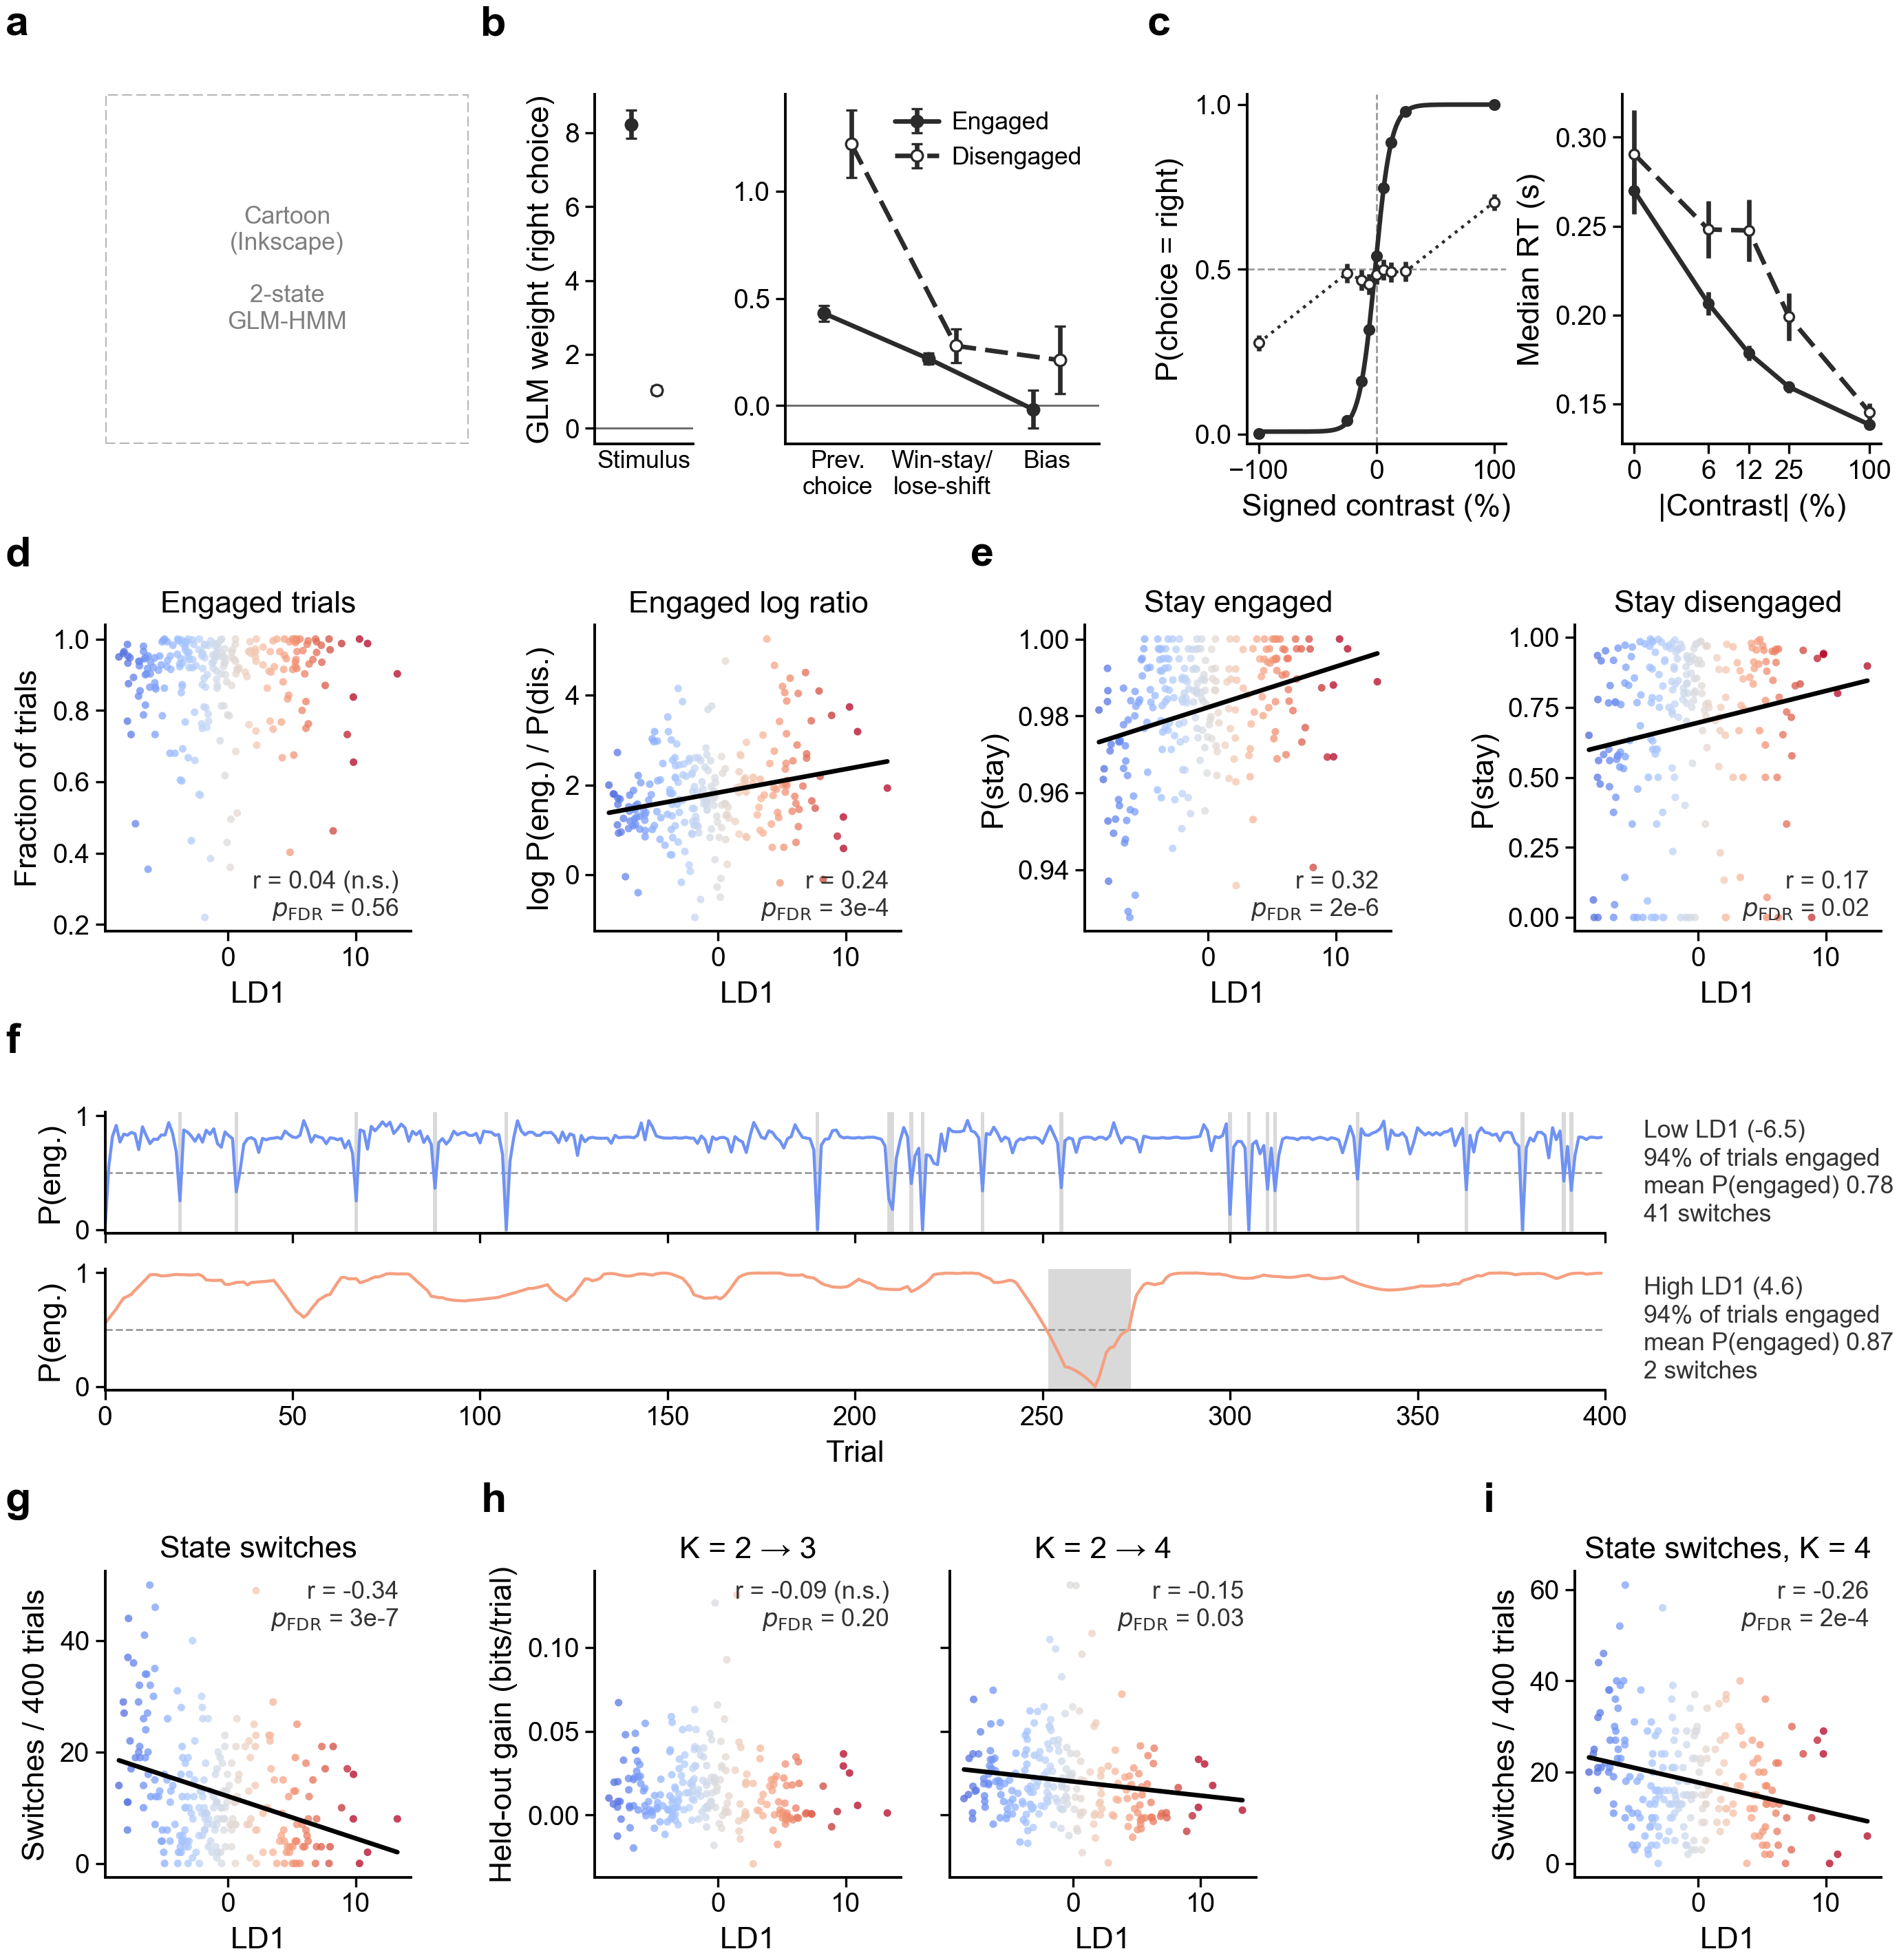

wrote figure_generation/figures/fig_engagement_08-10-2026.svg


wrote figure_generation/figures/fig_engagement.pdf


In [11]:
from datetime import date
LETTERS = {k: k.lower() for k in 'ABCDEFGHI'}
FIG_W, FIG_H = 7.09, 7.45

def letter(fig, axes, key, x=None, y=None):
    r_ = fig.canvas.get_renderer()
    if x is None:
        x = max(min(a.get_tightbbox(r_).transformed(fig.transFigure.inverted()).x0 for a in axes) - 0.005, 0.003)
    fig.text(x, y, LETTERS[key], fontsize=plt.rcParams['font.size'] + 3, fontweight='bold', ha='left', va='bottom')

fig = plt.figure(figsize=(FIG_W, FIG_H))
outer = fig.add_gridspec(4, 1, height_ratios=[1.7, 1.7, 1.35, 1.7], hspace=0.48,
                         left=0.075, right=0.985, top=0.955, bottom=0.075)
row1 = outer[0].subgridspec(1, 3, width_ratios=[1.6, 2.4, 3.0], wspace=0.3)
# rows 2-3: one grid column per scatter axis, so every scatter has the same size
nH = len(H_STEPS)
row2 = outer[1].subgridspec(1, 4, wspace=0.6)
row4 = outer[3].subgridspec(1, 2 + nH, wspace=0.6)
panels = {'A': draw_A(fig, row1[0]), 'B': draw_B(fig, row1[1]), 'C': draw_C(fig, row1[2], legend=False),   # b's legend covers both
          'D': draw_D(fig, [row2[0], row2[1]]), 'E': draw_E(fig, [row2[2], row2[3]]), 'F': draw_F(fig, outer[2]),
          'G': draw_G(fig, row4[0]), 'H': draw_H(fig, [row4[1 + i] for i in range(nH)]), 'I': draw_I(fig, row4[1 + nH])}

fig.canvas.draw()   # applies the square aspect, so the positions below are final
# b starts where d's second axis does (same axis left edge); a widens into the space this frees
inv = fig.transFigure.inverted()
r_ = fig.canvas.get_renderer()
bx = [a.get_position() for a in panels['B']]
x0_new, x1 = panels['D'][1].get_position().x0, bx[-1].x1
scale = (x1 - x0_new) / (x1 - bx[0].x0)
for a, p in zip(panels['B'], bx):
    a.set_position([x0_new + (p.x0 - bx[0].x0) * scale, p.y0, p.width * scale, p.height])
fig.canvas.draw()
pa = panels['A'][0].get_position()
a_right = panels['B'][0].get_tightbbox(r_).transformed(inv).x0 - 0.03
a_left = panels['D'][0].get_position().x0
panels['A'][0].set_position([a_left, pa.y0, a_right - a_left, pa.height])
# h: its first axis under b's (both start at d's second axis), the second next to it on a shared y,
# without the empty y-label gap a grid column leaves
hx = [a.get_position() for a in panels['H']]
lo = min(a.get_ylim()[0] for a in panels['H']); hi = max(a.get_ylim()[1] for a in panels['H'])
gap = 0.025
x = panels['D'][1].get_position().x0
for i, (a, p) in enumerate(zip(panels['H'], hx)):
    a.set_position([x, p.y0, p.width, p.height]); a.set_ylim(lo, hi)
    x += p.width + gap
    if i:
        a.sharey(panels['H'][0]); a.tick_params(labelleft=False)
fig.canvas.draw()
LEFT = ['A', 'D', 'F', 'G']
r_ = fig.canvas.get_renderer()
x_letter = max(min(panels[k][0].get_tightbbox(r_).transformed(fig.transFigure.inverted()).x0
                   for k in LEFT if k != 'A') - 0.005, 0.003)
top = lambda keys: max(a.get_position().y1 for k in keys for a in panels[k]) + 0.025
ROW_Y = {k: top(row) for row in ('ABC', 'DE', 'F', 'GHI') for k in row}
# b and h are one column: one x for their letters
bbox_x = lambda k: panels[k][0].get_tightbbox(r_).transformed(fig.transFigure.inverted()).x0 - 0.005
X_LETTER = {k: x_letter for k in LEFT}
X_LETTER.update(dict.fromkeys('BH', min(bbox_x('B'), bbox_x('H'))))
for k, axes in panels.items():
    letter(fig, axes, k, x=X_LETTER.get(k), y=ROW_Y[k])
plt.show()

OUT_DIR = PI / 'figure_generation' / 'figures'
OUT_DIR.mkdir(exist_ok=True)
for path in [OUT_DIR / f"{FIG}_{date.today().strftime('%d-%m-%Y')}.svg", OUT_DIR / f'{FIG}.pdf']:
    fig.savefig(path)
    print('wrote', path.relative_to(PI))